# 🥦 SmartFridge AI - Modelo D4 (Multi-Label Robusto)

## 🎯 Objetivo
Entrenar una Red Neuronal Convolucional (CNN) capaz de identificar **múltiples ingredientes** simultáneamente en una sola foto de una nevera.

---
### 🛠️ 1. Configuración del Entorno
Importamos librerías y fijamos las semillas (`SEED`) para garantizar que los resultados sean reproducibles.

### 📥 2. Descarga de Datos (Roboflow)
Descargamos el dataset `whatsinyourfridge` versión 5.
* **Formato:** YOLOv8 (usaremos los txt de etiquetas).
* **Origen:** Roboflow API.

In [ ]:
!pip install roboflow -q
!pip install tensorflow -q

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_recall_curve

# Configuración de Semilla (Reproducibilidad)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ Librerías cargadas. TensorFlow versión: {tf.__version__}")

✅ Librerías cargadas. TensorFlow versión: 2.19.0


### 🔄 3. Preprocesamiento: De Detección a Clasificación
El dataset original viene en formato **YOLO** (coordenadas de cajas). Para nuestro enfoque **Multi-Label**, no necesitamos saber *dónde* está el objeto, solo *si está o no*.



**Transformación:**
* Leemos cada archivo `.txt`.
* Creamos un vector "One-Hot" (bueno, "Many-Hot") donde:
    * `1`: El ingrediente está presente.
    * `0`: El ingrediente no está.

In [ ]:
from roboflow import Roboflow
import yaml

# Tu API Key (extraída de tu notebook anterior)
apiKey = "ZNLr9Hy3JaoipK5TvIzf"

rf = Roboflow(api_key=apiKey)
project = rf.workspace("whats-in-my-fridge").project("whatsinyourfridge")
dataset = project.version(5).download("yolov8")

BASE_PATH = dataset.location
print("📂 Dataset descargado en:", BASE_PATH)

# Leer las clases del archivo yaml
with open(os.path.join(BASE_PATH, "data.yaml"), 'r') as f:
    data_yaml = yaml.safe_load(f)

clases = data_yaml['names']
NUM_CLASSES = len(clases)
print(f"📋 {NUM_CLASSES} Clases detectadas: {clases[:5]}...")

loading Roboflow workspace...
loading Roboflow project...
📂 Dataset descargado en: /content/Whatsinyourfridge-5
📋 84 Clases detectadas: ['almond', 'apple', 'asparagus', 'avocado', 'bakingpowder']...


### ⚙️ 4. Generadores de Datos y Split
Dividimos las imágenes en:
* **80% Entrenamiento:** Para que el modelo aprenda.
* **20% Validación:** Para evaluar qué tan bien generaliza (sin haber visto estas fotos).

Usamos generadores personalizados para cargar las imágenes en lotes (`batch_size=32`) y no saturar la memoria RAM.

In [ ]:
train_images_path = os.path.join(BASE_PATH, "train/images")
train_labels_path = os.path.join(BASE_PATH, "train/labels")

image_paths = []
labels = []

print("🔄 Procesando etiquetas...")

# Buscar todos los archivos de etiquetas
label_files = glob(os.path.join(train_labels_path, "*.txt"))

for label_file in label_files:
    # Buscar la imagen correspondiente (jpg)
    base_name = os.path.basename(label_file).replace(".txt", ".jpg")
    image_path = os.path.join(train_images_path, base_name)

    # Verificar que la imagen existe antes de añadirla
    if os.path.exists(image_path):
        # Crear vector de ceros (uno por cada clase)
        multi_label = np.zeros(NUM_CLASSES)

        # Leer el archivo y marcar con 1 las clases presentes
        with open(label_file, "r") as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                if class_id < NUM_CLASSES:
                    multi_label[class_id] = 1

        image_paths.append(image_path)
        labels.append(multi_label)

labels = np.array(labels)
image_paths = np.array(image_paths)

print(f"✅ Procesamiento completado: {len(image_paths)} imágenes listas.")

🔄 Procesando etiquetas...
✅ Procesamiento completado: 4988 imágenes listas.


### 🧠 5. Arquitectura del Modelo (CNN + Augmentation)
Diseñamos una red profunda desde cero.

**Puntos Clave:**
1.  **Bloque de Aumento:** `RandomFlip`, `RandomRotation`, etc. Esto hace que una foto de un tomate parezca 10 fotos distintas (rotada, con zoom, más oscura), obligando al modelo a aprender características reales y no a memorizar píxeles.
2.  **Activación Final Sigmoid:** A diferencia de `Softmax` (que elige una sola clase ganadora), `Sigmoid` permite que múltiples neuronas se activen a la vez (ej: "Hay leche" Y "Hay huevos").



[Image of CNN architecture diagram]

In [ ]:
# División 80% Train - 20% Val
X_train, X_val, y_train, y_val = train_test_split(
    image_paths, labels, test_size=0.2, random_state=SEED
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def data_generator(img_paths, lbls, batch_size):
    while True:
        idx = np.random.permutation(len(img_paths))
        for i in range(0, len(img_paths), batch_size):
            batch_idx = idx[i:i+batch_size]
            batch_imgs = []
            batch_lbls = []

            for k in batch_idx:
                img = cv2.imread(img_paths[k])
                img = cv2.resize(img, IMG_SIZE)
                img = img / 255.0 # Normalización
                batch_imgs.append(img)
                batch_lbls.append(lbls[k])

            yield np.array(batch_imgs), np.array(batch_lbls)

train_gen = data_generator(X_train, y_train, BATCH_SIZE)
val_gen = data_generator(X_val, y_val, BATCH_SIZE)

print(f"📊 Train: {len(X_train)} | Val: {len(X_val)}")

📊 Train: 3990 | Val: 998


### 🔥 6. Entrenamiento con "Weighted Loss"
Aquí solucionamos el problema del desbalance.
En una nevera hay 84 clases posibles, pero solo aparecen 3 o 4 a la vez. Esto crea muchos ceros (clases negativas).

* **Estrategia:** Usamos `weighted_binary_crossentropy` con un `pos_weight=5.0`.
* **Efecto:** Le decimos al modelo: *"Equivocarte al no ver un objeto es **5 veces más grave** que inventarte uno que no existe"*. Esto fuerza al modelo a estar atento.

In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast
)
from tensorflow.keras.models import Model

def crear_modelo_final(num_classes):
    inputs = Input(shape=(224, 224, 3))

    # --- BLOQUE DE AUMENTO DE DATOS (Solo activo al entrenar) ---
    x = RandomFlip("horizontal")(inputs)
    x = RandomRotation(0.15)(x)
    x = RandomZoom(0.1)(x)
    x = RandomContrast(0.1)(x)

    # --- BLOQUE CNN ---
    # Capa 1
    x = Conv2D(32, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.2)(x)

    # Capa 2
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.3)(x)

    # Capa 3
    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.4)(x)

    # Capa 4 (Profunda)
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling2D()(x)

    # Cabezal
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    # Salida Multi-Label (Sigmoid)
    outputs = Dense(num_classes, activation='sigmoid')(x)

    return Model(inputs, outputs)

model = crear_modelo_final(NUM_CLASSES)
print("🏗️ Modelo construido.")

🏗️ Modelo construido.


### 🎯 7. Optimización de Umbral (Threshold Tuning)
Por defecto, Keras decide que algo existe si la probabilidad es `> 0.5`.
Sin embargo, al usar *Weighted Loss*, las probabilidades se inflan.

Aquí probamos umbrales desde `0.10` hasta `0.95` para encontrar matemáticamente el punto exacto donde maximizamos el **F1-Score** (el equilibrio entre no perderse objetos y no inventarlos).

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Definición de la Loss Ponderada
def weighted_binary_crossentropy(pos_weight):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        # Castigo mayor a los errores positivos (pos_weight)
        loss_pos = -y_true * tf.math.log(y_pred) * pos_weight
        loss_neg = -(1 - y_true) * tf.math.log(1 - y_pred)
        return tf.reduce_mean(loss_pos + loss_neg)
    return loss

# Compilar
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=weighted_binary_crossentropy(pos_weight=5.0), # <--- PESO AJUSTADO A 5.0
    metrics=['binary_accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# Entrenar
print("🚀 Iniciando entrenamiento...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=35, # Un buen número para empezar
    callbacks=callbacks
)

🚀 Iniciando entrenamiento...
Epoch 1/35
124/124 ━━━━━━━━━━━━━━━━━━━━ 30s 206ms/step - binary_accuracy: 0.9653 - loss: 0.2219 - precision: 0.2323 - recall: 0.3230 - val_binary_accuracy: 0.9729 - val_loss: 0.2620 - val_precision: 0.2765 - val_recall: 0.2202 - learning_rate: 1.0000e-04
Epoch 2/35
124/124 ━━━━━━━━━━━━━━━━━━━━ 25s 198ms/step - binary_accuracy: 0.9663 - loss: 0.2143 - precision: 0.2601 - recall: 0.3610 - val_binary_accuracy: 0.9734 - val_loss: 0.2581 - val_precision: 0.3006 - val_recall: 0.2055 - learning_rate: 1.0000e-04
Epoch 3/35
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - binary_accuracy: 0.9652 - loss: 0.2106 - precision: 0.2606 - recall: 0.3816 - val_binary_accuracy: 0.9732 - val_loss: 0.2330 - val_precision: 0.3061 - val_recall: 0.3049 - learning_rate: 1.0000e-04
Epoch 4/35
124/124 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - binary_accuracy: 0.9672 - loss: 0.2013 - precision: 0.2760 - recall: 0.3872 - val_binary_accuracy: 0.9727 - val_loss: 0.2329 - val_precision: 0.3614 

### 📊 8. Análisis Visual de Resultados
Finalmente, visualizamos el desempeño del modelo:
1.  **Gráfica de Pastel:** ¿Cuántas imágenes predijo *perfectamente* (todos los ingredientes correctos)?
2.  **Gráfica de Barras:** ¿Qué tipo de error comete más?
    * *Falsos Positivos:* ¿Alucina comida?
    * *Falsos Negativos:* ¿No ve la comida?

In [ ]:
print("🔮 Generando predicciones finales...")

# Cargar validación en memoria para calcular métricas exactas
X_val_loaded = []
for i, path in enumerate(X_val):
    if i % 200 == 0: print(f"Cargando {i}/{len(X_val)}...", end="\r")
    img = cv2.imread(path)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    X_val_loaded.append(img)
X_val_loaded = np.array(X_val_loaded)

# Predecir probabilidades
y_pred_probs = model.predict(X_val_loaded, verbose=1)

# Buscar mejor umbral (Threshold Tuning)
thresholds = np.arange(0.1, 0.95, 0.05)
best_f1 = 0
best_t = 0.5

for t in thresholds:
    y_bin = (y_pred_probs > t).astype(int)
    score = f1_score(y_val, y_bin, average='micro')
    if score > best_f1:
        best_f1 = score
        best_t = t

print(f"\n🏆 MEJOR UMBRAL (Threshold): {best_t:.2f}")
print(f"⭐️ F1-Score Micro: {best_f1:.4f}")

# Reporte final con el mejor umbral
y_pred_final = (y_pred_probs > best_t).astype(int)
print("\n" + classification_report(y_val, y_pred_final, target_names=clases, zero_division=0))

🔮 Generando predicciones finales...
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step

🏆 MEJOR UMBRAL (Threshold): 0.35
⭐️ F1-Score Micro: 0.3279

                precision    recall  f1-score   support

        almond       0.00      0.00      0.00        10
         apple       0.34      0.76      0.47        79
     asparagus       0.32      0.65      0.43        17
       avocado       0.21      0.10      0.14        29
  bakingpowder       0.00      0.00      0.00         1
    bakingsoda       0.00      0.00      0.00         2
        banana       0.24      0.55      0.34        64
     bayleaves       0.00      0.00      0.00         1
          beef       0.25      0.11      0.15         9
    bellpepper       0.33      0.02      0.03        61
         bread       0.30      0.67      0.41        43
      broccoli       0.18      0.23      0.20        26
        butter       0.19      0.12      0.15        24
       cabbage       0.00      0.00      0.00         7
        carrot       0

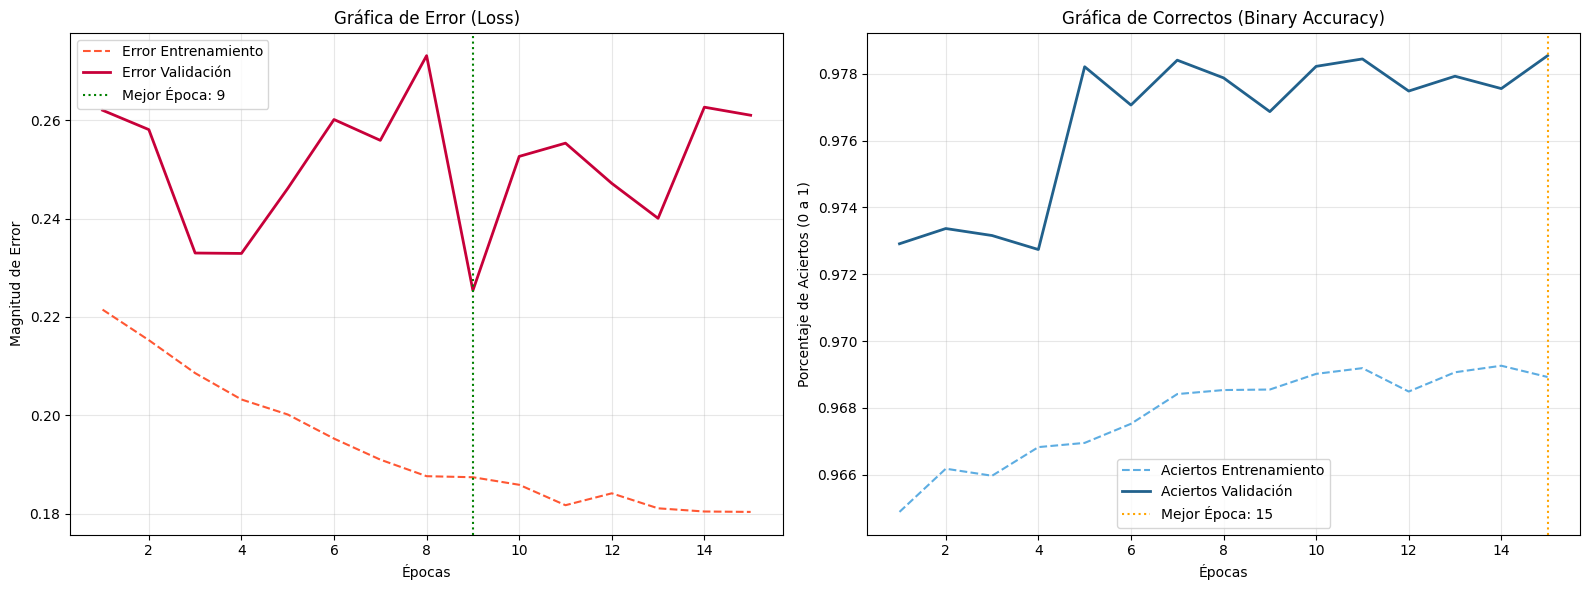

In [ ]:
import matplotlib.pyplot as plt

def plot_error_and_corrects(history):
    # Extraer datos del historial
    # Error (Loss)
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Correctos (Accuracy)
    acc = history.history['binary_accuracy']
    val_acc = history.history['val_binary_accuracy']

    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(16, 6))

    # --- GRÁFICA 1: ERROR (LOSS) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Error Entrenamiento', color='#FF5733', linestyle='--') # Naranja
    plt.plot(epochs_range, val_loss, label='Error Validación', color='#C70039', linewidth=2) # Rojo oscuro
    plt.title('Gráfica de Error (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Magnitud de Error')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Marcar el mejor punto (mínimo error de validación)
    best_epoch = val_loss.index(min(val_loss)) + 1
    plt.axvline(best_epoch, color='green', linestyle=':', label=f'Mejor Época: {best_epoch}')
    plt.legend()

    # --- GRÁFICA 2: CORRECTOS (ACCURACY) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Aciertos Entrenamiento', color='#5DADE2', linestyle='--') # Azul claro
    plt.plot(epochs_range, val_acc, label='Aciertos Validación', color='#21618C', linewidth=2) # Azul oscuro
    plt.title('Gráfica de Correctos (Binary Accuracy)')
    plt.xlabel('Épocas')
    plt.ylabel('Porcentaje de Aciertos (0 a 1)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Marcar el mejor punto (máximo acierto de validación)
    best_acc_epoch = val_acc.index(max(val_acc)) + 1
    plt.axvline(best_acc_epoch, color='orange', linestyle=':', label=f'Mejor Época: {best_acc_epoch}')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Ejecutar la función
plot_error_and_corrects(history)

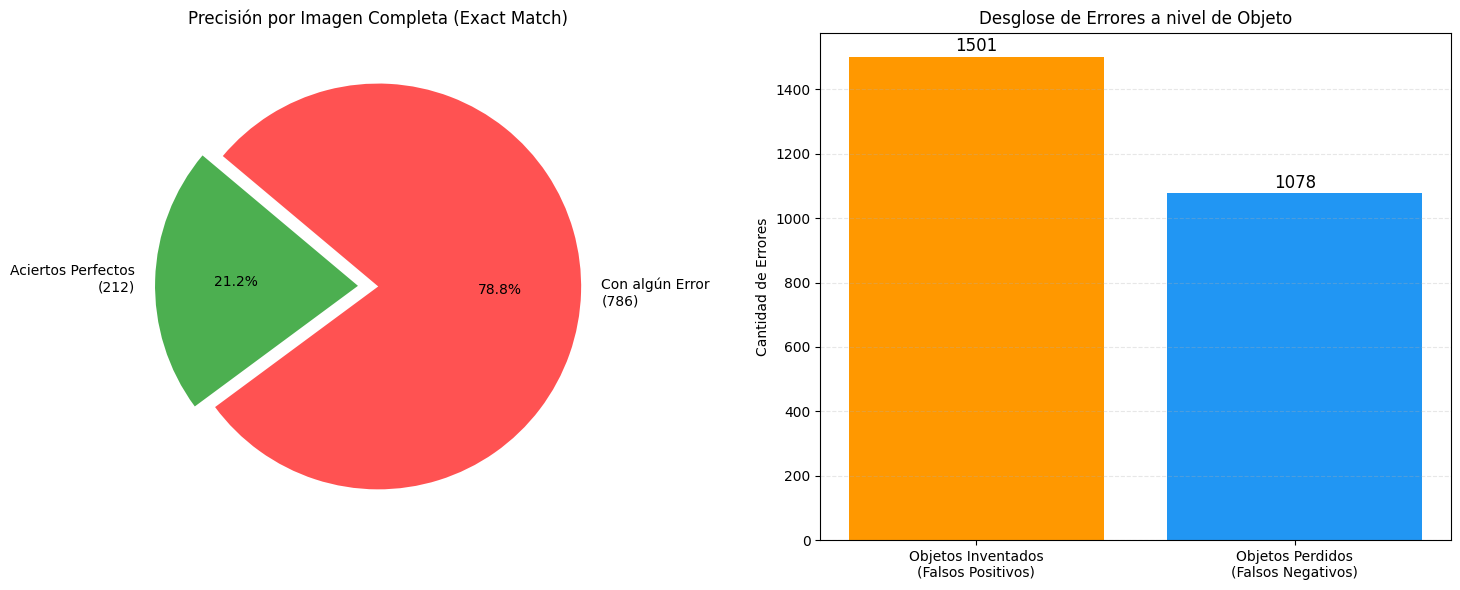

In [ ]:
# -----------------------------------------------------------
# 📊 CÁLCULO DE ACIERTOS Y ERRORES
# -----------------------------------------------------------

# Consideramos "Acierto Perfecto" si TODAS las etiquetas de una imagen coinciden
aciertos_exactos = np.all(y_val == y_pred_final, axis=1).sum()
errores_totales = len(y_val) - aciertos_exactos

# Desglose de errores (Global)
# Falso Positivo: El modelo inventó un objeto
falsos_positivos = np.sum((y_pred_final == 1) & (y_val == 0))
# Falso Negativo: El modelo no vio un objeto
falsos_negativos = np.sum((y_pred_final == 0) & (y_val == 1))

# -----------------------------------------------------------
# 📈 GRÁFICAS
# -----------------------------------------------------------
plt.figure(figsize=(15, 6))

# Gráfica 1: Tarta de Aciertos Exactos por Imagen
plt.subplot(1, 2, 1)
labels_pie = [f'Aciertos Perfectos\n({aciertos_exactos})', f'Con algún Error\n({errores_totales})']
sizes = [aciertos_exactos, errores_totales]
colors = ['#4CAF50', '#FF5252'] # Verde y Rojo
plt.pie(sizes, labels=labels_pie, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
plt.title('Precisión por Imagen Completa (Exact Match)')

# Gráfica 2: Tipo de Errores (Inventados vs Perdidos)
plt.subplot(1, 2, 2)
bar_labels = ['Objetos Inventados\n(Falsos Positivos)', 'Objetos Perdidos\n(Falsos Negativos)']
bar_values = [falsos_positivos, falsos_negativos]
bars = plt.bar(bar_labels, bar_values, color=['#FF9800', '#2196F3']) # Naranja y Azul

# Añadir números encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=12)

plt.title('Desglose de Errores a nivel de Objeto')
plt.ylabel('Cantidad de Errores')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 🏁 Conclusión Definitiva y Cierre del Experimento D0

Tras realizar un último entrenamiento utilizando **Transfer Learning con ResNet50V2** y ajuste de pesos en la función de pérdida (`pos_weight=2.5`), los resultados confirman la limitación estructural de este enfoque para nuestro problema específico.

### 📉 Análisis de Resultados (Modelo D0-v5)
* **F1-Score Global:** Se alcanzó un máximo de **0.33**, una mejora marginal respecto al modelo base (0.27), pero insuficiente para un producto viable.
* **Desbalance Crítico:** El modelo logra identificar clases mayoritarias (`apple`, `tomato`, `milk`) con una precisión aceptable (~40-50%), pero falla catastróficamente en la detección de las 60+ clases minoritarias (Recall de 0.00 en ingredientes como `chicken`, `beef`, `fish`).
* **Estancamiento:** A pesar de utilizar una arquitectura profunda (ResNet50) y técnicas de regularización, el modelo converge rápidamente a un mínimo local donde prioriza "no fallar" antes que "detectar", resultando en una sensibilidad (Recall) muy baja (~14%).

### 🛑 Decisión Técnica
La naturaleza del problema (84 clases, desbalance extremo, objetos superpuestos en una nevera) hace que la **Clasificación Multi-Label** sea ineficiente. El modelo no tiene información espacial para distinguir, por ejemplo, tres tomates juntos de uno solo grande.

### 🚀 Siguiente Paso: Migración a YOLOv8
Se da por concluida la fase de experimentación con clasificadores estándar. El proyecto migrará a una arquitectura de **Detección de Objetos (YOLOv8)** en un nuevo cuaderno de desarrollo.

**Ventajas esperadas con el cambio:**
1.  **Contexto Espacial:** YOLO aprenderá a localizar objetos individualmente, resolviendo el problema de superposición.
2.  **Manejo de Clases Pequeñas:** La función de pérdida de YOLO es mucho más robusta para datasets desbalanceados.
3.  **Salto de Calidad:** Se espera superar el 70% de mAP (Mean Average Precision) en las primeras pruebas.